Размер обучающей выборки: (90839, 29)
Доля хитов: 4.27%

Начинаем честную оптимизацию гиперпараметров. Это займет пару минут...

Обучение и оптимизация: Decision Tree (Gini)...


C:\Users\Danya\AppData\Local\Temp\ipykernel_24496\2845376213.py:59: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='grey')


Обучение и оптимизация: Decision Tree (Entropy)...
Обучение и оптимизация: Random Forest...
Обучение и оптимизация: Gradient Boosting...


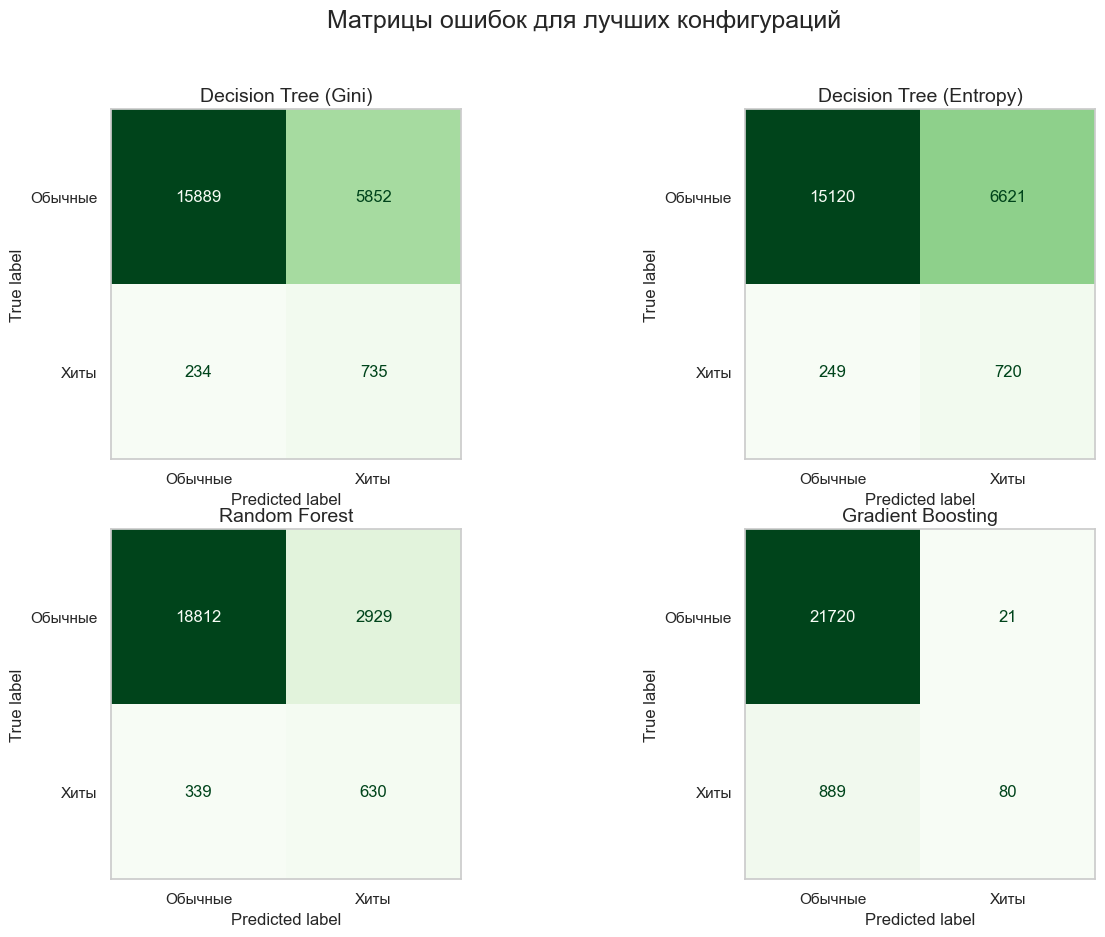

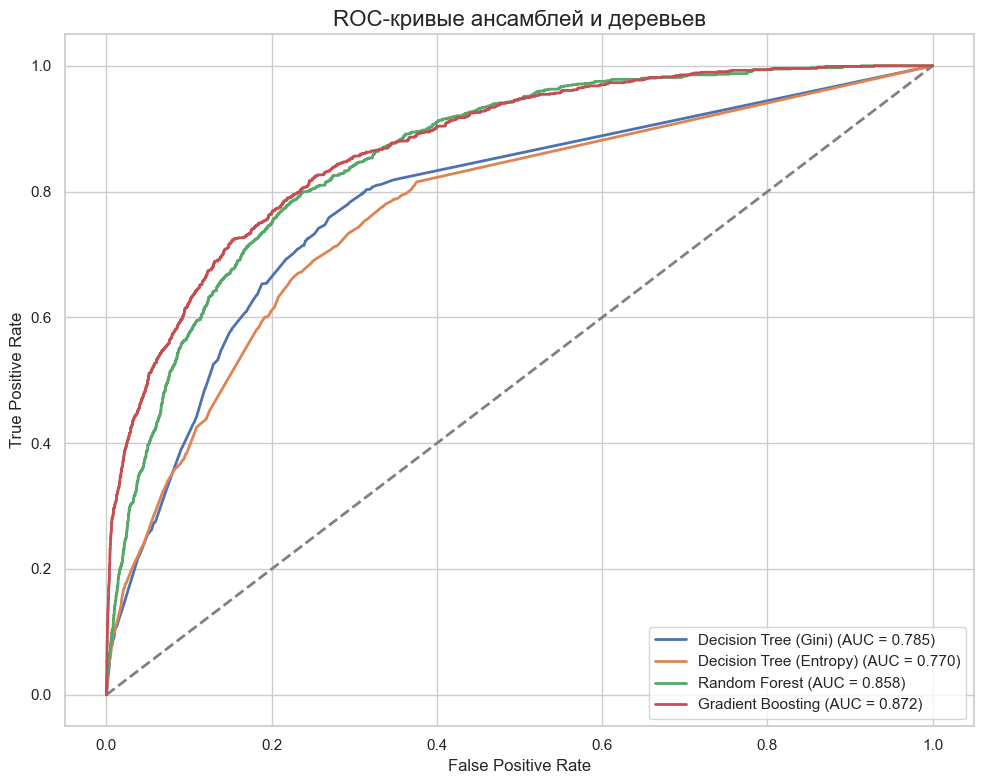


--- Итоговая таблица результатов ---


,Алгоритм,Лучшие параметры,Accuracy,F1-score,AUC-ROC
0,Decision Tree (Gini),"{'max_depth': 15, 'max_features': None}",0.732012,0.194547,0.785460
1,Decision Tree (Entropy),"{'max_depth': 15, 'max_features': None}",0.697490,0.173285,0.769777
2,Random Forest,"{'max_depth': 15, 'max_features': 'log2'}",0.856099,0.278269,0.857703
3,Gradient Boosting,"{'max_depth': 7, 'max_features': None}",0.959930,0.149533,0.871682


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --- 1. Подготовка данных ---
df = pd.read_csv('dataset_standardized.csv')

# Создаем бинарный таргет: Хиты (популярность > 70)
df['Target'] = np.where(df['popularity'] > 70, 1, 0)

cols_to_drop = ['popularity', 'Target', 'track_id', 'artists', 'album_name', 'track_name']
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Target']

# Разбиваем на трейн и тест с сохранением баланса
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Доля хитов: {y.mean():.2%}\n")
print("Начинаем честную оптимизацию гиперпараметров. Это займет пару минут...\n")

# --- 2. Настройка сеток параметров (СТРОГО ПО ЗАДАНИЮ) ---
# Разделяем Дерево на Джини и Энтропию явно!
models_params = {
    'Decision Tree (Gini)': {
        'model': DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42),
        'params': {'max_depth': [3, 5, 10, 15], 'max_features': [None, 'sqrt', 'log2']}
    },
    'Decision Tree (Entropy)': {
        'model': DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42),
        'params': {'max_depth': [3, 5, 10, 15], 'max_features': [None, 'sqrt', 'log2']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
        'params': {'max_depth': [5, 10, 15], 'max_features': ['sqrt', 'log2']}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'params': {'max_depth': [3, 5, 7], 'max_features': [None, 'sqrt']}
    }
}

results =[]

# Холст для матриц ошибок (теперь 2х2)
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(15, 10))
fig_cm.suptitle('Матрицы ошибок для лучших конфигураций', fontsize=18)
axes_cm = axes_cm.flatten() # Вытягиваем в линию для удобства цикла

# Холст для ROC-кривой
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', lw=2, color='grey') 

# --- 3. Обучение и оценка ---
for i, (name, mp) in enumerate(models_params.items()):
    print(f"Обучение и оптимизация: {name}...")
    
    grid = GridSearchCV(mp['model'], mp['params'], scoring='f1', cv=3, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)[:, 1] 
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_score)
    
    results.append({
        'Алгоритм': name,
        'Лучшие параметры': str(grid.best_params_),
        'Accuracy': acc,
        'F1-score': f1,
        'AUC-ROC': auc
    })
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Обычные', 'Хиты'])
    disp.plot(ax=axes_cm[i], cmap='Greens', colorbar=False)
    axes_cm[i].set_title(name, fontsize=14)
    axes_cm[i].grid(False)
    
    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

# Настройки графика ROC
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые ансамблей и деревьев', fontsize=16)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 4. Вывод итоговой таблицы ---
results_df = pd.DataFrame(results)

# Снимаем ограничение на ширину колонки для красоты
pd.set_option('display.max_colwidth', None)

print("\n--- Итоговая таблица результатов ---")
display(results_df)

pd.reset_option('display.max_colwidth')

Выводы по моделям на основе деревьев решений

1. Сравнение критериев разбиения Gini и Entropy:
При оптимизации одиночного дерева индекс Джини показал более высокие результаты, чем энтропия Шеннона при одинаковых оптимальных гиперпараметрах (max_depth=15, max_features=None). Джини обеспечил меньшее количество FP срабатываний.
2. Влияние гиперпараметров:
Для одиночных деревьев и Случайного леса оптимальной оказалась глубина 15 — задача требует сложных цепочек правил. При этом Случайный лес задействовал логарифмическое ограничение признаков (max_features='log2'), что является ключевым фактором для создания разнообразия (декорреляции) базовых деревьев в ансамбле. Градиентный бустинг ограничился глубиной 7, так как последовательное построение глубоких деревьев ведет к мгновенному переобучению.
3. Сравнение производительности и выбор лучшей модели:
Random Forest (Лучшая модель): Безоговорочный лидер по F1-мере (0.278). Использование ансамбля и встроенной балансировки весов позволило сократить количество ложных срабатываний в два раза по сравнению с одиночным деревом, сохранив высокую полноту (Recall).
Gradient Boosting: Показал наивысшую разделяющую способность (AUC-ROC = 0.872), но провалился по F1 (0.149). Отсутствие параметра class_weight в стандартной реализации привело к тому, что алгоритм максимизировал общую Accuracy (0.960), игнорируя миноритарный класс (найдено всего 80 хитов).
Decision Tree: Одиночные деревья оказались слишком слабыми обобщающими моделями для данных с сильным дисбалансом. Несмотря на высокую полноту, они генерируют критически большой объем шума (около 6000 FP).
Итог: Для выбранного набора данных лучше всего подходит алгоритм Random Forest. Ансамблевые методы на основе деревьев продемонстрировали существенное превосходство над базовыми линейными моделями из предыдущих работ.

Обучаем неглубокое дерево (max_depth=3) специально для красивой визуализации...


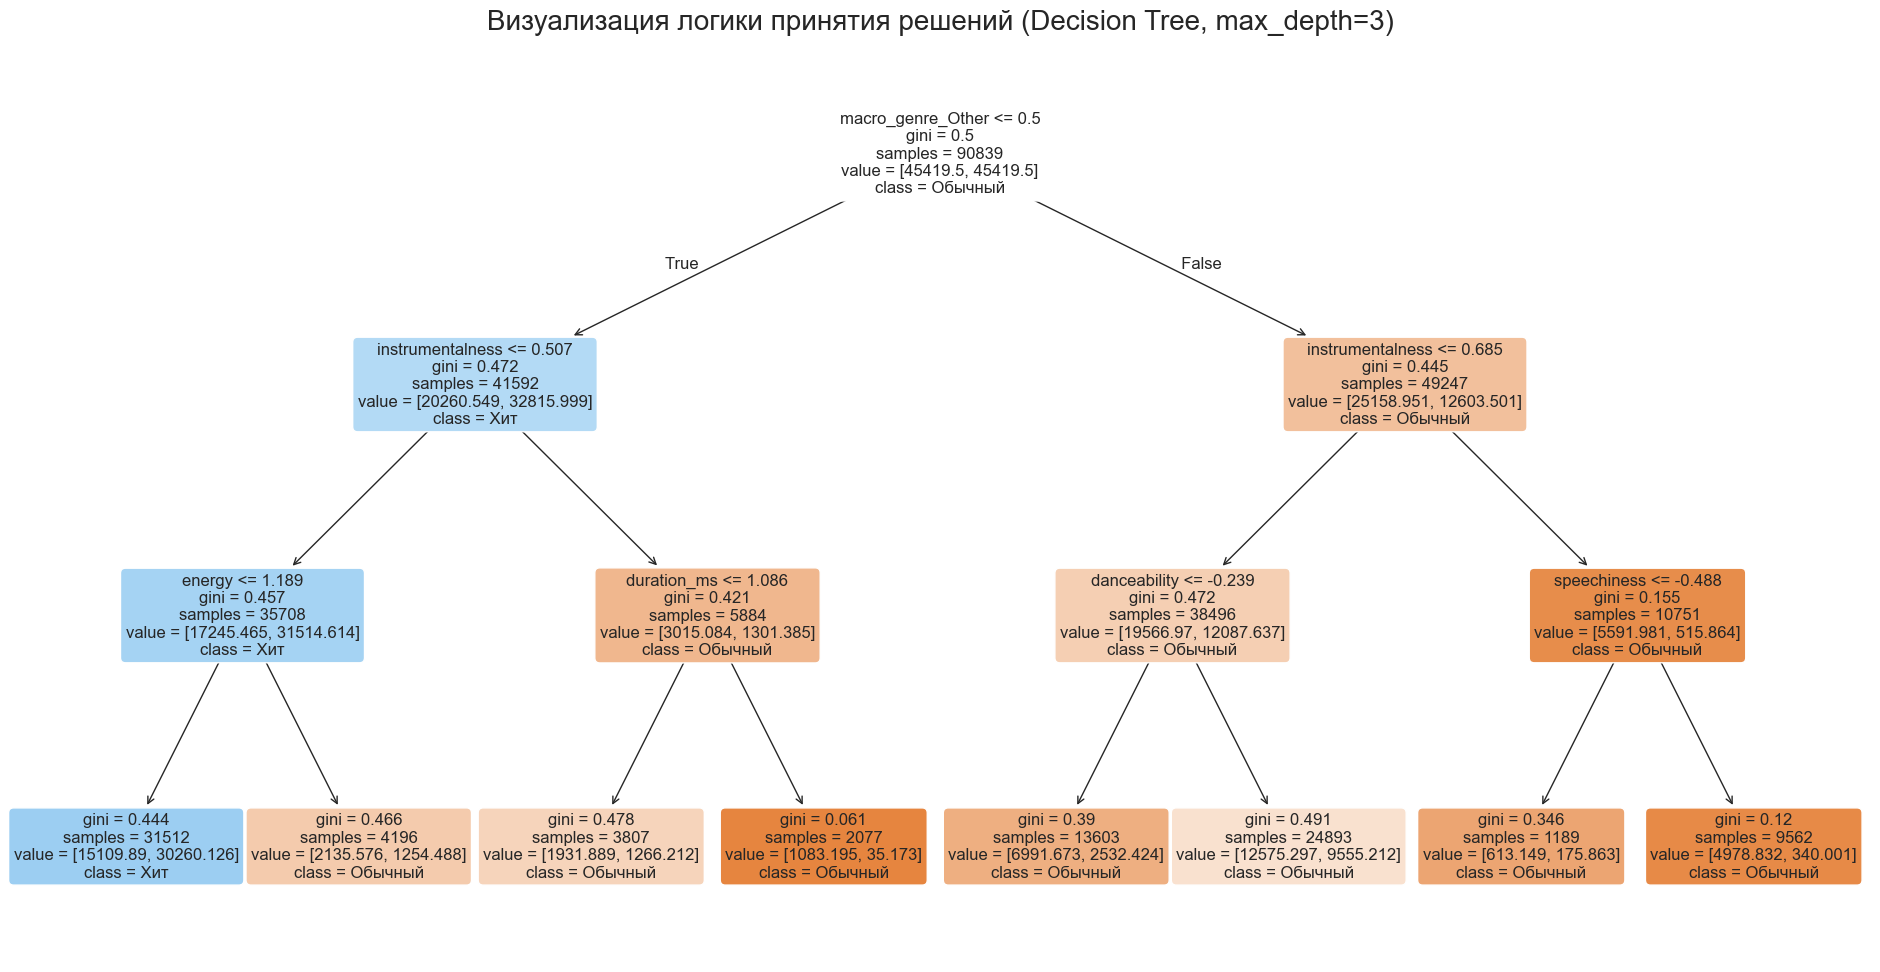

In [2]:
from sklearn.tree import plot_tree

# --- Задание 5: Визуализация дерева решений ---
print("Обучаем неглубокое дерево (max_depth=3) специально для красивой визуализации...")

# Обучаем демонстрационное дерево
demo_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
demo_tree.fit(X_train, y_train)

# Настраиваем большой холст
plt.figure(figsize=(24, 12))

# Рисуем дерево
# feature_names - подставит реальные названия колонок (tempo, loudness и тд)
# class_labels - подставит названия классов
# filled=True - раскрасит квадратики (зеленый для одного класса, оранжевый для другого)
plot_tree(
    demo_tree, 
    feature_names=X.columns, 
    class_names=['Обычный', 'Хит'], 
    filled=True, 
    rounded=True, 
    fontsize=12
)

plt.title("Визуализация логики принятия решений (Decision Tree, max_depth=3)", fontsize=20)
plt.show()